# Classification Part A Comparison

**Owner: Student 3 | Review 1 - Classification Part A**  
This notebook consolidates the five required Part A classifiers on the same stratified test split.

,Rank,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC
1,1,KNN Classifier,0.968,0.968,0.968,0.967,0.972
3,2,Decision Tree Classifier,0.957,0.957,0.957,0.957,0.932
4,3,Support Vector Classifier,0.954,0.954,0.954,0.953,0.955
0,4,Logistic Regression,0.857,0.865,0.857,0.828,0.761
2,5,Gaussian Naive Bayes,0.830,0.811,0.830,0.810,0.708


Best model by F1_weighted: KNN Classifier (0.9670)


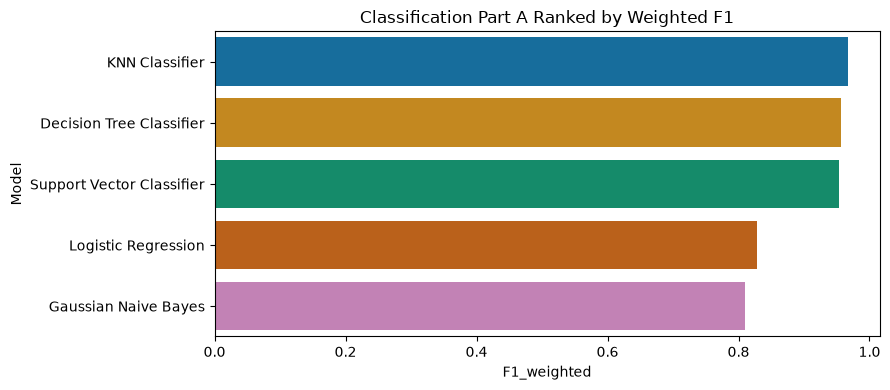

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

results_dir = repo_root / "student_work" / "student_3" / "results"
comparison = pd.concat(
    [pd.read_csv(path) for path in sorted(results_dir.glob("*.csv"))], ignore_index=True
).sort_values("F1_weighted", ascending=False)
comparison.insert(0, "Rank", range(1, len(comparison) + 1))
display(comparison.round(3))
best = comparison.iloc[0]
print(f"Best model by F1_weighted: {best['Model']} ({best['F1_weighted']:.4f})")
assert len(comparison) == 5

plt.figure(figsize=(9, 4))
sns.barplot(data=comparison, x="F1_weighted", y="Model", hue="Model", palette="colorblind", legend=False)
plt.title("Classification Part A Ranked by Weighted F1")
plt.tight_layout()
plt.show()

Weighted F1 is the primary ranking because the smoker classes are imbalanced. Accuracy, weighted precision and recall, confusion matrices, and ROC-AUC remain visible in each algorithm notebook.